# IMC-Denoise: a content aware denoising pipeline to enhance imaging mass cytometry

Here we will show an example for denoising the images with marker CD14 from our own human bone marrow IMC dataset. 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tp
from IMC_Denoise.IMC_Denoise_main.DIMR import DIMR
from IMC_Denoise.IMC_Denoise_main.DeepSNiF import DeepSNiF

### Load the pre-trained denoisng model for a marker

In [42]:
channel_name = "CD45"
weights_name = "weights_"+channel_name+".hdf5" # trained network weights name. 
weights_save_directory = None # location where 'weights_name' will be loaded. 
# If the value is None, the files will be loaded from the default directory.
is_load_weights = True # read from the saved one.
deepsnif = DeepSNiF(weights_name = weights_name,
                  weights_dir = weights_save_directory, 
                  is_load_weights = is_load_weights)

Pre-trained model /home/giuseppe/devices/Delta_Tissue/IMC/IMC_Denoise/application_results/trained_weights/weights_CD45.hdf5 loaded successfully.
Pre-calculated range value file /home/giuseppe/devices/Delta_Tissue/IMC/IMC_Denoise/application_results/trained_weights/weights_CD45_range_val.npz loaded successfully.


### Load a raw CD14 image

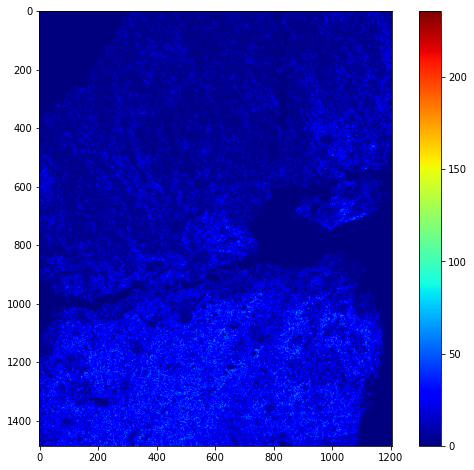

In [43]:
# read a CD14 raw image.
Raw_img_name = "/home/giuseppe/devices/Delta_Tissue/IMC/split_channels_nohpf/Leap042_6/"+channel_name+'.tiff' # change to your raw image name
Img_raw = tp.imread(Raw_img_name)
plt.figure(figsize = (10,8))
plt.imshow(Img_raw, vmin = 0, vmax = 0.5*np.max(Img_raw), cmap = 'jet')
plt.colorbar()
plt.show()

### Perform the DIMR algorithm only if the SNR of the raw image is high.

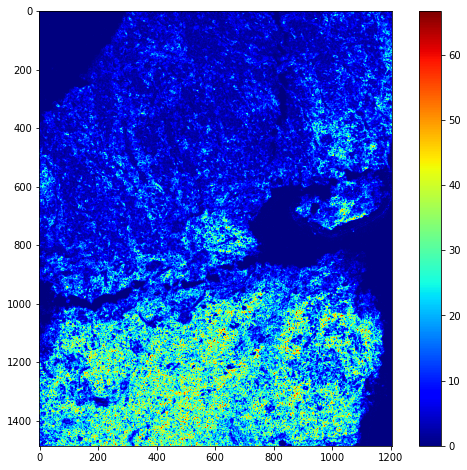

In [44]:
n_neighbours = 10 # Larger n enables removing more consecutive hot pixels. 
n_iter = 3 # Iteration number for DIMR
window_size = 5 # Slide window size. For IMC images, window_size = 3 is fine.
Img_DIMR = DIMR(n_neighbours = n_neighbours, n_iter = n_iter, window_size = window_size).perform_DIMR(Img_raw)
plt.figure(figsize = (10,8))
plt.imshow(Img_DIMR, vmin = 0, vmax = 0.5*np.max(Img_DIMR), cmap = 'jet')
plt.colorbar()
plt.show()

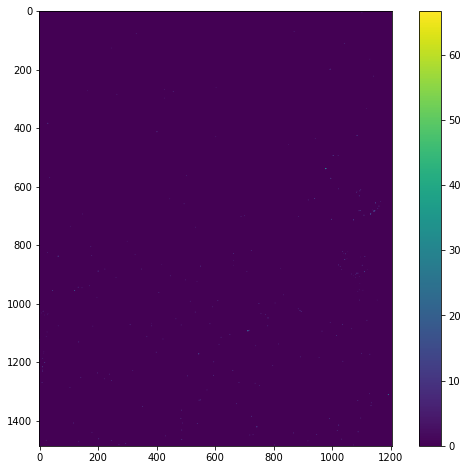

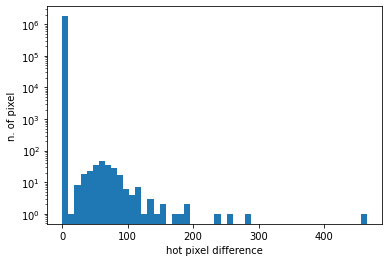

In [56]:
plt.figure(figsize = (10,8))
plt.imshow(Img_raw-Img_DIMR,vmax = Img_DIMR.max()/2)
plt.colorbar()
np.max(Img_raw),np.max(Img_DIMR)
plt.figure()
plt.hist(np.abs(Img_raw-Img_DIMR).reshape(-1),50)
plt.ylabel('n. of pixel')
plt.xlabel('hot pixel difference')
plt.semilogy()
#plt.savefig('figures/pixel_difference.png')

### If the SNR of the raw image is sub-optimal, perform DIMR and DeepSNiF algorithms for low SNR raw images.
If errors happen, check if the GPUs are being used by other sessions. If yes, shutdown the session occupying GPUs and re-run the prediction.

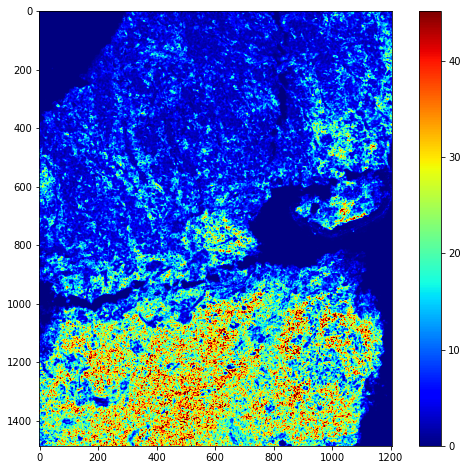

In [46]:
# perform DIMR and DeepSNiF algorithms for low SNR raw images.
Img_DIMR_DeepSNiF = deepsnif.perform_IMC_Denoise(Img_raw, n_neighbours = n_neighbours, n_iter = n_iter, window_size = window_size)
plt.figure(figsize = (10,8))
plt.imshow(Img_DIMR_DeepSNiF, vmin = 0, vmax = 0.5*np.max(Img_DIMR_DeepSNiF), cmap = 'jet')
plt.colorbar()
plt.show()

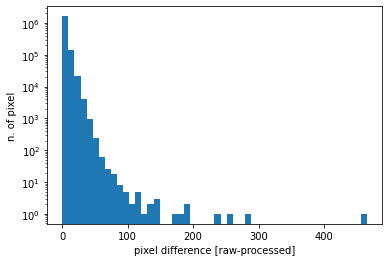

In [55]:
plt.hist(np.abs(Img_raw-Img_DIMR_DeepSNiF).reshape(-1),50)
plt.semilogy()
plt.ylabel('n. of pixel')
plt.xlabel('pixel difference [raw-processed]')
#plt.savefig('figures/pixel_difference2.png')

## Compare to hpf that it was

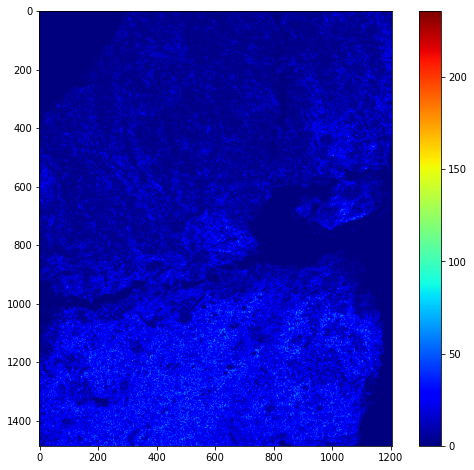

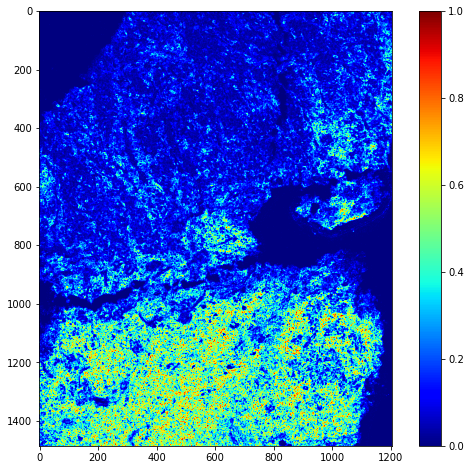

In [47]:
hpf_img_name = Raw_img_name.replace('_nohpf','') # change to your raw image name
Img_hpf = tp.imread(hpf_img_name)
plt.figure(figsize = (10,8))
plt.imshow(Img_hpf, vmin = 0, vmax = 0.5*np.max(Img_raw), cmap = 'jet')
plt.colorbar()
plt.figure(figsize = (10,8))
q = np.quantile(Img_raw.reshape(-1),0.99)
a = Img_raw/q
a[a>1]=1
plt.imshow(a, vmin = 0, vmax = np.max(a), cmap = 'jet')
plt.colorbar()

In [48]:
np.count_nonzero(Img_raw != Img_hpf)
np.stack((Img_raw,Img_hpf),axis = 0)[:,Img_raw != Img_hpf].T

array([[ 90.16537  ,  31.77054  ],
       [471.77274  ,  53.2138   ],
       [133.00763  ,  13.395449 ],
       [ 83.10074  ,  23.702164 ],
       [ 78.25233  ,  13.898214 ],
       [ 88.00449  ,   2.3511848],
       [111.44045  ,  48.15117  ],
       [122.49578  ,  15.772523 ],
       [ 77.98612  ,  18.863033 ],
       [169.24374  ,   4.0998015],
       [ 97.0452   ,  16.00355  ],
       [ 77.10628  ,   5.959286 ],
       [114.41455  ,   7.441696 ],
       [ 83.28554  ,  11.3326025],
       [186.44693  ,  11.567388 ],
       [261.61603  ,  25.964611 ],
       [240.31683  ,   4.3677835],
       [121.93215  ,  49.435745 ],
       [ 60.503918 ,   8.698611 ],
       [130.65466  ,  26.439713 ],
       [178.86873  , 102.74402  ],
       [ 61.174862 ,   8.033198 ],
       [ 78.592445 ,   9.781815 ],
       [ 83.44817  ,   2.4140308],
       [ 77.36319  ,  13.44347  ],
       [ 84.23374  ,   5.2162023],
       [ 83.65707  ,   9.175488 ],
       [ 89.51833  ,   8.393674 ],
       [ 62.13791  ,

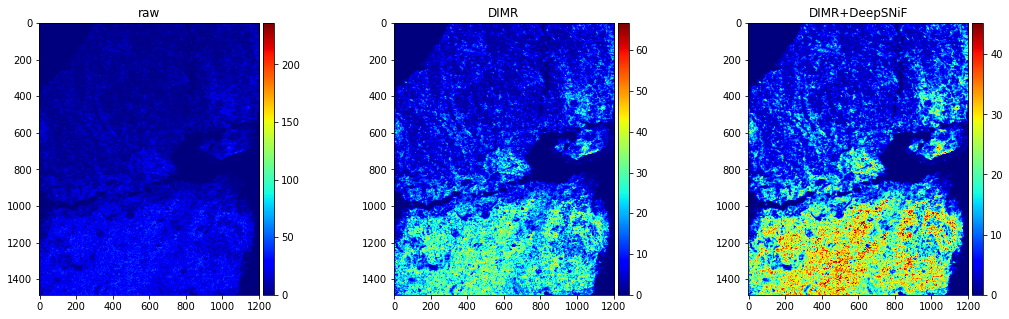

In [50]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(nrows=1, ncols=3,figsize =(18,5) )
im1 = ax[0].imshow(Img_raw, vmin = 0, vmax = 0.5*np.max(Img_raw), cmap = 'jet')
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im1, cax=cax, orientation='vertical')
ax[0].set_title('raw')

im2 = ax[1].imshow(Img_DIMR, vmin = 0, vmax = 0.5*np.max(Img_DIMR), cmap = 'jet')
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im2, cax=cax, orientation='vertical')
ax[1].set_title('DIMR')

ax[2].set_title('DIMR+DeepSNiF')
im3 = ax[2].imshow(Img_DIMR_DeepSNiF, vmin = 0, vmax = 0.5*np.max(Img_DIMR_DeepSNiF), cmap = 'jet')
divider = make_axes_locatable(ax[2])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im3, cax=cax, orientation='vertical')
#plt.savefig('figures/comparison.png')

In [1]:
import matplotlib.pyplot as plt

In [17]:
Raw_img_name.replace('_nohpf','')

'/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap042_6/CD8a.tiff'

In [12]:
import tensorflow as tf

In [32]:
tf.keras.utils.save_img('figures/'+channel_name+'_Leap042_6.tiff',np.expand_dims(Img_DIMR_DeepSNiF,axis = 0),scale = False,data_format="channels_first")

In [24]:
tf.keras.utils.save_img?

Signature:
tf.keras.utils.save_img(
    path,
    x,
    data_format=None,
    file_format=None,
    scale=True,
    **kwargs,
)
Docstring:
Saves an image stored as a Numpy array to a path or file object.

Args:
    path: Path or file object.
    x: Numpy array.
    data_format: Image data format,
        either "channels_first" or "channels_last".
    file_format: Optional file format override. If omitted, the
        format to use is determined from the filename extension.
        If a file object was used instead of a filename, this
        parameter should always be used.
    scale: Whether to rescale image values to be within `[0, 255]`.
    **kwargs: Additional keyword arguments passed to `PIL.Image.save()`.
File:      ~/anaconda3/envs/IMC_Denoise/lib/python3.6/site-packages/keras/preprocessing/image.py
Type:      function
